# Ship Detection in Satellite Images with YOLO11 - v3

## Practical Work — AI Diploma: Computer Vision

---

Fine-tune YOLO11 to detect **ships** in **satellite images**, running entirely in a local Python environment.

### Pipeline
```
Kaggle Dataset        Roboflow             YOLO11 Training       Deploy
(Satellite images) -> (Ship annotation) -> (Fine-tuning)      -> (API)
```

## Prerequisites

1. Install dependencies: `uv sync`
2. Create a `.env` file in the project root with the following keys:
   ```
   ROBOFLOW_API_KEY=your_roboflow_key
   KAGGLE_USERNAME=your_kaggle_username
   KAGGLE_KEY=your_kaggle_api_key
   ```
   - Roboflow key: https://app.roboflow.com/settings/api
   - Kaggle key: https://kaggle.com/settings → API → Create New Token

---
## Section 0: Environment Setup

In [2]:
!nvidia-smi

Mon Jun  1 17:56:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.91                 Driver Version: 573.91         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000 Laptop GPU  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   51C    P8             16W /  101W |    2999MiB /   8192MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import ultralytics
from IPython.display import Image as IPyImage, display

ROOT = Path.cwd()
DATASETS_DIR = ROOT / "datasets"
RUNS_DIR = ROOT / "runs"
MODELS_DIR = ROOT / "models"
KAGGLE_DIR = DATASETS_DIR / "ships_satellite"
KAGGLE_DATASET = "rhammell/ships-in-satellite-imagery"
MODEL_NAME = "yolo11m.pt"

DATASETS_DIR.mkdir(exist_ok=True)
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Project root : {ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {device}")
ultralytics.checks()

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)


Setup complete  (12 CPUs, 63.7 GB RAM, 837.5/952.6 GB disk)


In [4]:
torch.cuda.is_available()

True

In [5]:
from dotenv import load_dotenv

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME")
KAGGLE_KEY = os.getenv("KAGGLE_KEY")

missing = [
    k
    for k, v in {
        "ROBOFLOW_API_KEY": ROBOFLOW_API_KEY,
        "KAGGLE_USERNAME": KAGGLE_USERNAME,
        "KAGGLE_KEY": KAGGLE_KEY,
    }.items()
    if not v
]

if missing:
    raise ValueError(f"Missing keys in .env: {', '.join(missing)}")

# Write kaggle.json expected by the kaggle CLI
kaggle_config_dir = Path.home() / ".kaggle"
kaggle_config_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_config_dir / "kaggle.json"
kaggle_json.write_text(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
kaggle_json.chmod(0o600)

print("Secrets loaded successfully.")

Secrets loaded successfully.


---
## Section 1: Kaggle Dataset Download

The **Satellite Images of Water Bodies** dataset (franciscoescobar) contains ~2,800 satellite images
organised in four categories: `sea`, `lake`, `river`, `swamp`.

We focus on `sea` images, which have the highest likelihood of containing ships.

In [6]:
import kaggle

# The kaggle API unzips into a subfolder that mirrors the zip structure:
# KAGGLE_DIR / "shipsnet" / "shipsnet" / *.png
SHIPSNET_DIR = KAGGLE_DIR / "shipsnet" / "shipsnet"

if SHIPSNET_DIR.exists() and any(SHIPSNET_DIR.iterdir()):
    print("Dataset already present — skipping download.")
else:
    print("Downloading dataset from Kaggle...")
    kaggle.api.dataset_download_files(
        KAGGLE_DATASET,
        path=str(KAGGLE_DIR),
        unzip=True,
    )
    print("Download complete.")

ship_images = list(SHIPSNET_DIR.glob("1__*.png"))
nonship_images = list(SHIPSNET_DIR.glob("0__*.png"))

print(f"\nshipsnet directory : {SHIPSNET_DIR}")
print(f"  ship chips       : {len(ship_images)}")
print(f"  non-ship chips   : {len(nonship_images)}")
print(f"  total            : {len(ship_images) + len(nonship_images)}")

Dataset already present — skipping download.

shipsnet directory : c:\Users\leona\source\repos\diplo-mod-2\datasets\ships_satellite\shipsnet\shipsnet
  ship chips       : 1000
  non-ship chips   : 3000
  total            : 4000


Ship chips     : 1000
Non-ship chips : 3000


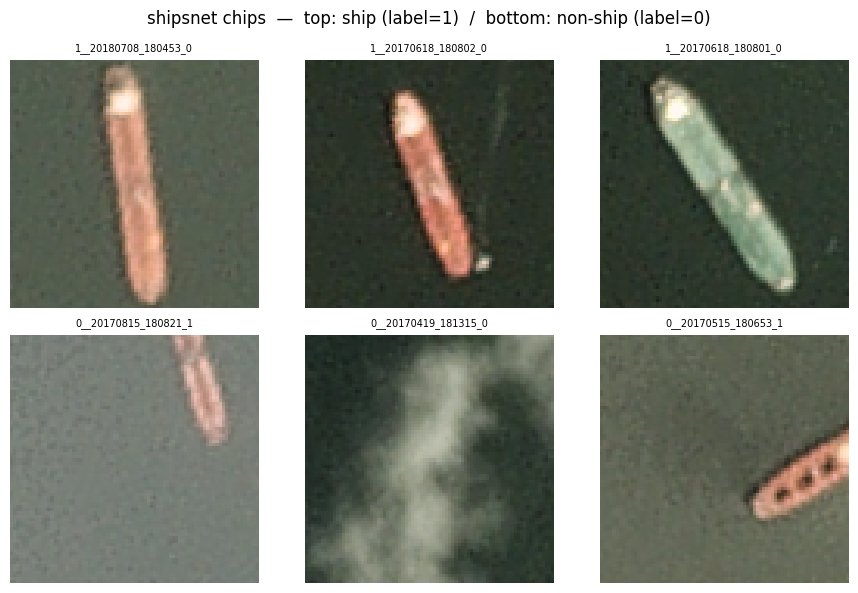


Width  — min: 80, max: 80, mean: 80px
Height — min: 80, max: 80, mean: 80px


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

if "SHIPSNET_DIR" not in dir():
    SHIPSNET_DIR = KAGGLE_DIR / "shipsnet" / "shipsnet"
    ship_images = list(SHIPSNET_DIR.glob("1__*.png"))
    nonship_images = list(SHIPSNET_DIR.glob("0__*.png"))

print(f"Ship chips     : {len(ship_images)}")
print(f"Non-ship chips : {len(nonship_images)}")

ship_sample = random.sample(ship_images, min(3, len(ship_images)))
nonship_sample = random.sample(nonship_images, min(3, len(nonship_images)))

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
fig.suptitle("shipsnet chips  —  top: ship (label=1)  /  bottom: non-ship (label=0)", fontsize=12)

for ax, img_path in zip(axes[0], ship_sample):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(img_path.name[:20], fontsize=7)
    ax.axis("off")

for ax, img_path in zip(axes[1], nonship_sample):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(img_path.name[:20], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

size_sample = random.sample(
    ship_images + nonship_images, min(50, len(ship_images) + len(nonship_images))
)
widths, heights = zip(*[Image.open(p).size for p in size_sample])
print(f"\nWidth  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}px")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}px")

---
## Section 2: Image Annotation in Roboflow

The Kaggle dataset has no ship bounding boxes. Annotation must be done in Roboflow before training.

### Steps (done manually on the web)
1. Go to [app.roboflow.com](https://app.roboflow.com) → New Project → Object Detection
2. Name: `ship-detection-satellite` — Class: `ship`
3. Upload images from the `sea/` folder (200–500 is a good starting point)
4. Annotate ships using the bounding box tool. Use **Auto Label** (Grounding DINO / SAM) to speed up the process
5. Generate dataset: 70/20/10 train/valid/test split, enable augmentations (rotate, flip, brightness)
6. Export as **YOLOv11** format

> **Quick alternative:** use a pre-annotated ship dataset from Roboflow Universe
> (search for `ship satellite` at universe.roboflow.com).

In [8]:
# Optional: upload images programmatically instead of via the web UI
from roboflow import Roboflow
from tqdm import tqdm

WORKSPACE_NAME = "leonardos-workspace-yllzl"
PROJECT_NAME = "ship-4jnj0-ku1a7"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)

upload_sample = random.sample(ship_images, min(300, len(ship_images)))
print(f"Uploading {len(upload_sample)} images to Roboflow...")

for img_path in tqdm(upload_sample, unit="img"):
    project.upload(str(img_path), batch_name="kaggle-shipsnet-batch-1")

print("Upload complete. Annotate the ships at app.roboflow.com before continuing.")

loading Roboflow workspace...
loading Roboflow project...
Uploading 300 images to Roboflow...


100%|██████████| 300/300 [02:54<00:00,  1.72img/s]

Upload complete. Annotate the ships at app.roboflow.com before continuing.


---
## Section 3: Download Annotated Dataset from Roboflow

Once annotation and dataset generation are done in Roboflow, download it here.

In [8]:
from roboflow import Roboflow

WORKSPACE_NAME = "leonardos-workspace-yllzl"
PROJECT_NAME = "ship-4jnj0-ku1a7"
VERSION_NUMBER = 1

ROBOFLOW_DIR = DATASETS_DIR / "roboflow_annotated"

if (ROBOFLOW_DIR / "data.yaml").exists():
    print(f"Annotated dataset already present at {ROBOFLOW_DIR} — skipping download.")
else:
    print(f"Connecting to Roboflow project '{PROJECT_NAME}'...")
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)

    print(f"Downloading version {VERSION_NUMBER} in yolov11 format...")
    project.version(VERSION_NUMBER).download("yolov11", location=str(ROBOFLOW_DIR))
    print("Download complete.")

DATA_YAML = ROBOFLOW_DIR / "data.yaml"
print(f"\nDataset location : {ROBOFLOW_DIR}")
print(f"data.yaml        : {DATA_YAML}")

Annotated dataset already present at c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated — skipping download.

Dataset location : c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated
data.yaml        : c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\data.yaml


In [7]:
print("Dataset statistics:")
print("-" * 40)

for split in ["train", "valid", "test"]:
    img_dir = ROBOFLOW_DIR / split / "images"
    label_dir = ROBOFLOW_DIR / split / "labels"
    if not img_dir.exists():
        continue
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    ann_count = sum(
        len([line for line in p.read_text().splitlines() if line.strip()])
        for p in label_dir.glob("*.txt")
    )
    print(f"  {split:8s}: {len(images):4d} images, {ann_count:5d} ship annotations")

print("-" * 40)

Dataset statistics:
----------------------------------------
  train   : 1535 images,  7488 ship annotations
  valid   :  512 images,  2606 ship annotations
  test    :  512 images,  2768 ship annotations
----------------------------------------


---
## Section 4: Fine-tuning YOLO11

| Parameter | Value | Reason |
|-----------|-------|--------|
| `model`   | yolo11m | Better feature extraction for small objects (ships = ~20px) |
| `epochs`  | 100 | 10 epochs is insufficient for convergence |
| `imgsz`   | 640 | Balanced memory/precision for RTX A4000 |
| `patience` | 30 | Early stopping to prevent overfitting |
| `degrees` | 30 | Satellites capture ships at any angle |
| `flipud`  | 0.5 | No absolute "up" in satellite images |
| `mosaic`  | 1.0 | Significantly improves detection of small objects |

In [ ]:
from ultralytics import YOLO
from ultralytics.utils.downloads import safe_download

FORCE_RETRAIN = True  # set to True to start a new experiment ignoring existing runs

existing_runs = sorted(
    (RUNS_DIR / "detect").glob("ship_detection_v1*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)

if existing_runs and not FORCE_RETRAIN:
    BEST_WEIGHTS = existing_runs[-1]
    TRAIN_DIR = BEST_WEIGHTS.parent.parent
    print("Existing training run found — skipping training.")
    print(f"  Run      : {TRAIN_DIR}")
    print(f"  Weights  : {BEST_WEIGHTS}")
    print("\nSet FORCE_RETRAIN = True to start a new experiment.")
else:
    MODEL_PATH = MODELS_DIR / MODEL_NAME
    if not MODEL_PATH.exists():
        print(f"Downloading {MODEL_NAME} to {MODELS_DIR}...")
        safe_download(
            url=f"https://github.com/ultralytics/assets/releases/latest/download/{MODEL_NAME}",
            file=MODEL_PATH,
        )
        print(f"Saved to {MODEL_PATH}")
    else:
        print(f"Model already present at {MODEL_PATH}")

    model = YOLO(str(MODEL_PATH))
    results = model.train(
        data=str(DATA_YAML),
        epochs=100,
        imgsz=640,
        batch=-1,
        patience=30,
        device=device,
        cos_lr=True,
        lrf=0.01,
        weight_decay=0.0005,
        warmup_epochs=3,
        cls=1.5,
        degrees=30.0,
        flipud=0.5,
        fliplr=0.5,
        scale=0.5,
        shear=2.0,
        mosaic=1.0,
        mixup=0.1,
        copy_paste=0.1,
        plots=True,
        name="ship_detection_v1",
        project=str(RUNS_DIR / "detect"),
    )

    TRAIN_DIR = Path(results.save_dir)
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"
    print(f"\nTraining complete. Results saved to: {TRAIN_DIR}")

Model already present at c:\Users\leona\source\repos\diplo-mod-2\models\yolo11m.pt
New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
engine\trainer: task=detect, mode=train, model=c:\Users\leona\source\repos\diplo-mod-2\models\yolo11m.pt, data=c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\data.yaml, epochs=100, time=None, patience=30, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=c:\Users\leona\source\repos\diplo-mod-2\runs\detect, name=ship_detection_v14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, s

100%|██████████| 5.35M/5.35M [00:00<00:00, 12.3MB/s]


AMP: checks passed 
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% CUDA memory utilization.
AutoBatch: CUDA:0 (NVIDIA RTX A4000 Laptop GPU) 8.00G total, 3.16G reserved, 0.46G allocated, 4.38G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output
    20053779       68.19         0.931         82.24         67.98        (1, 3, 640, 640)                    list
    20053779       136.4         1.460         51.42         32.08        (2, 3, 640, 640)                    list
    20053779       272.8         2.485         55.92         44.25        (4, 3, 640, 640)                    list
    20053779       545.5         4.467         95.18         79.61        (8, 3, 640, 640)                    list
    20053779        1091         8.470         888.8          1097       (16, 3, 640, 640)                    list
AutoBatch: Using batch-size 4 for CUDA:0 6.08G/8.00G (76%) 


train: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\train\labels.cache... 1535 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1535/1535 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 14, len(boxes) = 7488. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

    100/100      2.73G      1.656       3.66       1.48          4        640: 100%|██████████| 384/384 [00:54<00:00,  7.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 64/64 [00:06<00:00,  9.29it/s]

                   all        512       2606      0.693      0.455      0.492      0.248



100 epochs completed in 1.821 hours.
Optimizer stripped from c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v14\weights\last.pt, 40.5MB
Optimizer stripped from c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v14\weights\best.pt, 40.5MB

Validating c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v14\weights\best.pt...
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 64/64 [00:06<00:00,  9.98it/s]


                   all        512       2606      0.689      0.457      0.492      0.251
Speed: 0.3ms preprocess, 7.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v14

Training complete. Results saved to: c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v14


---
## Section 5: Training Results

In [12]:
BEST_WEIGHTS = ROOT / "runs" / "detect" / "ship_detection_v14" / "weights" / "best.pt"

Training run: c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v15

confusion_matrix_normalized.png


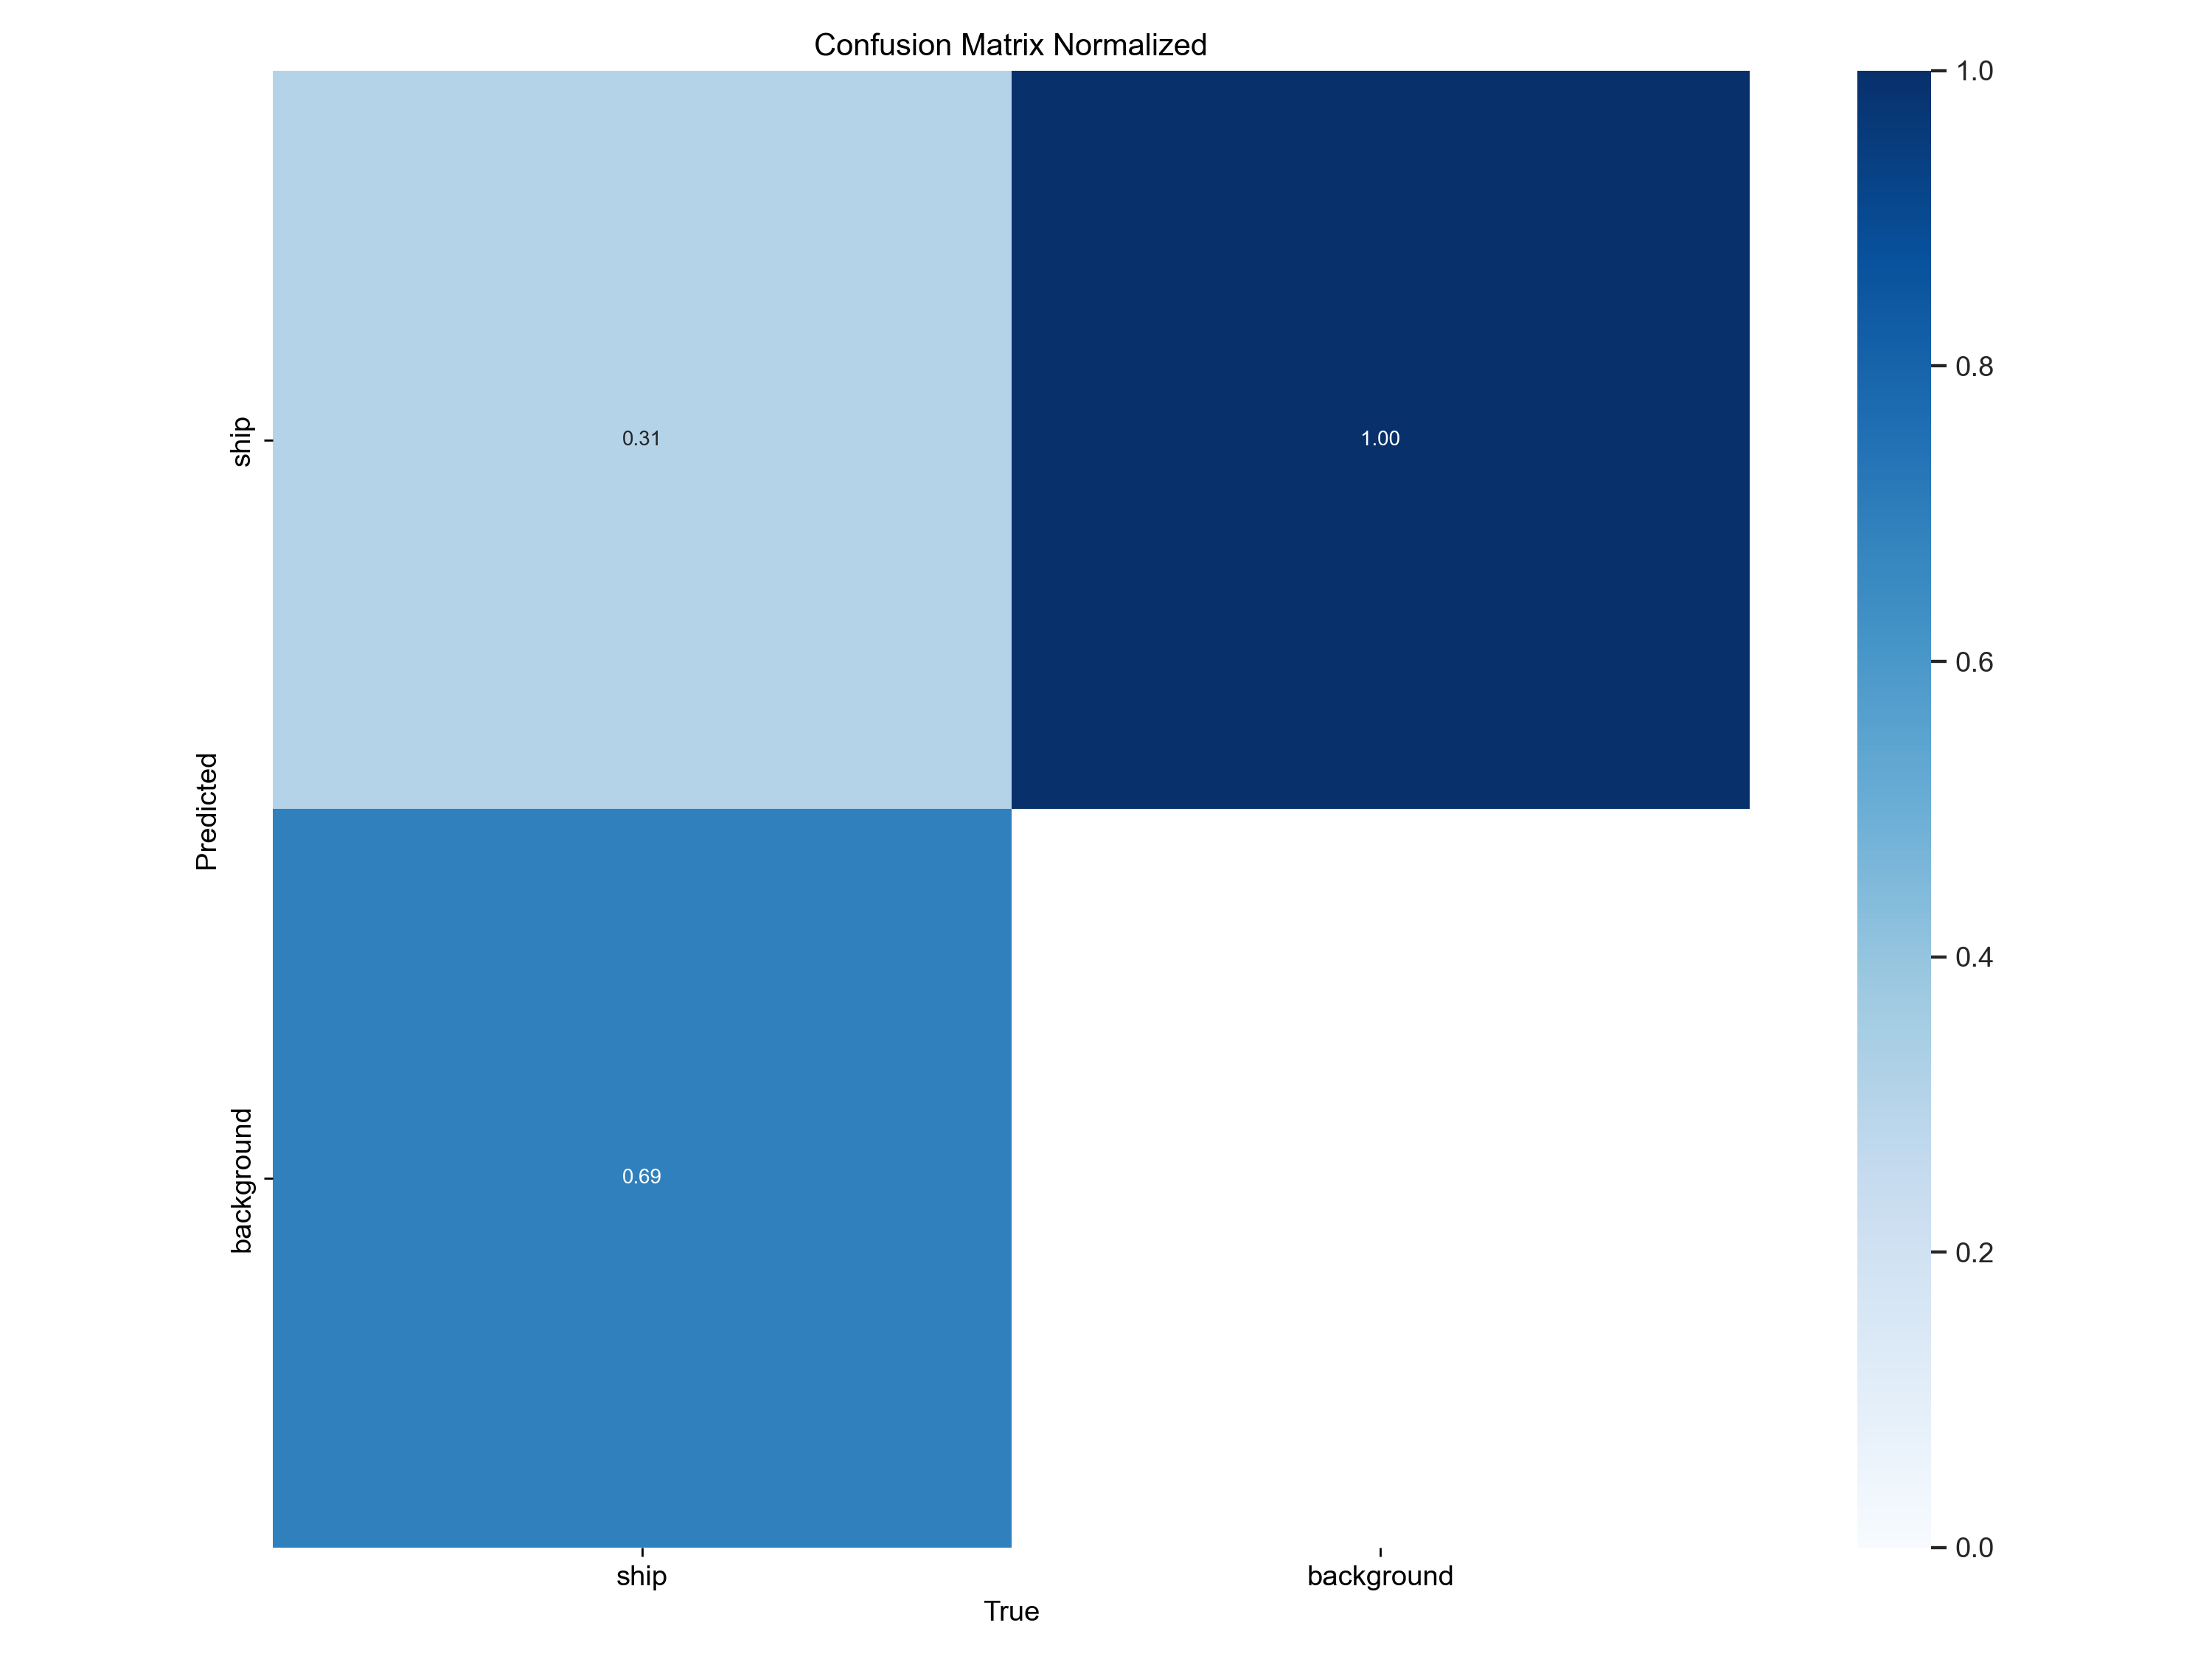


results.png


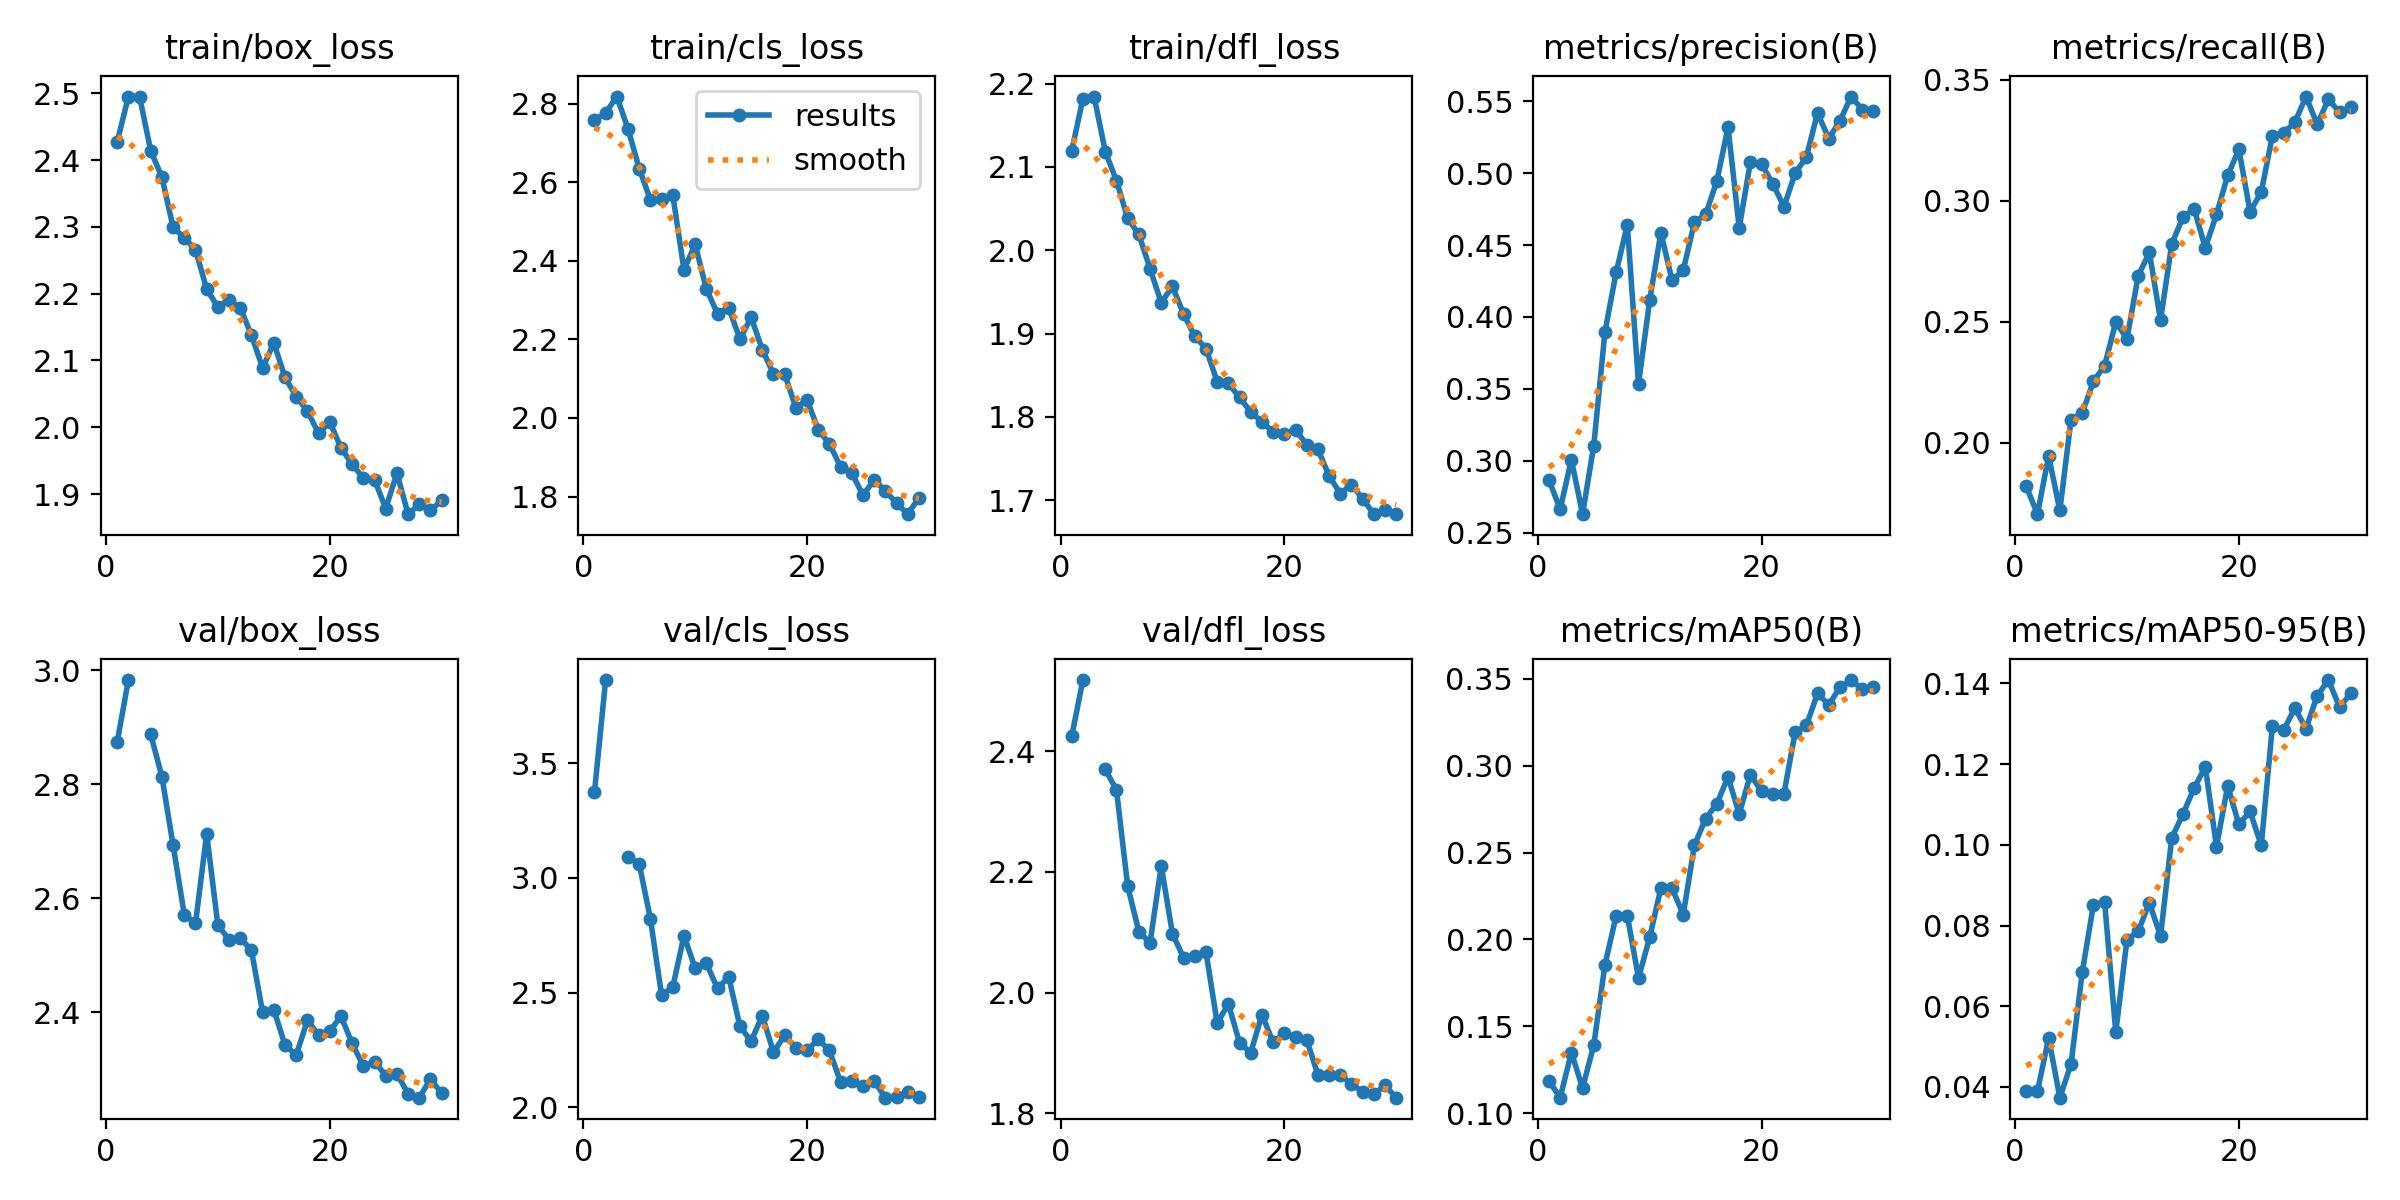


val_batch0_pred.jpg


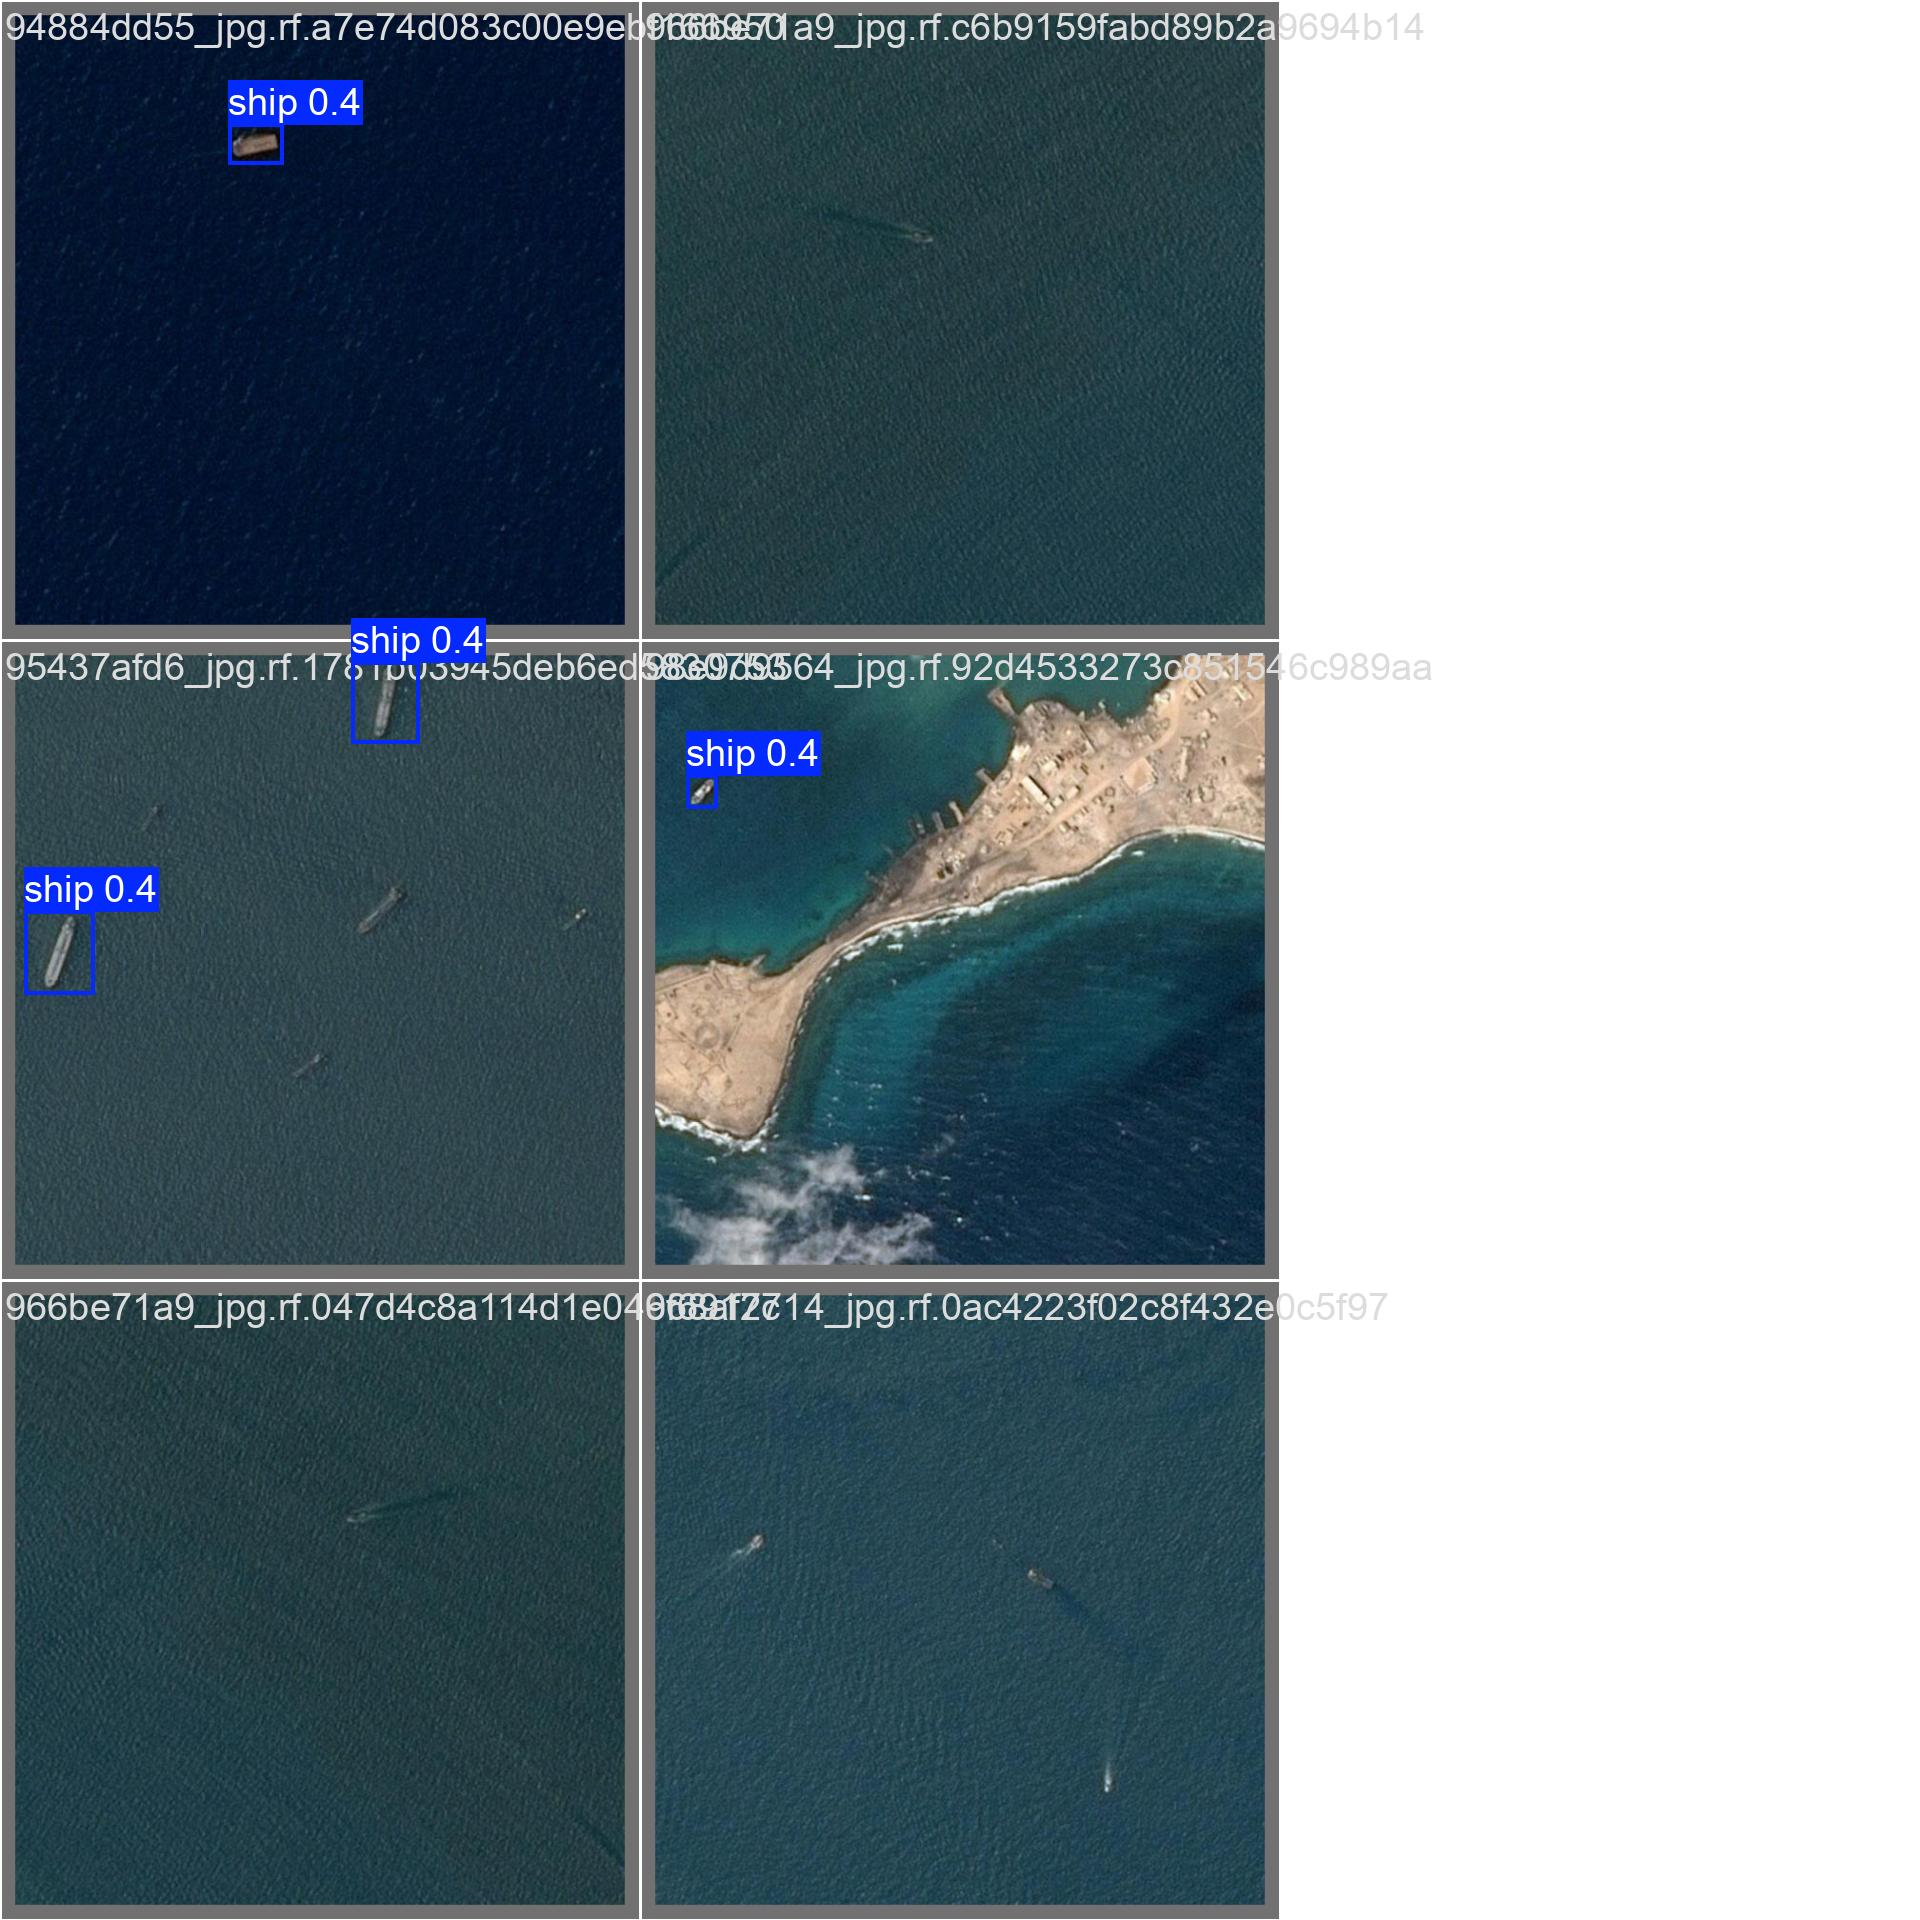

In [13]:
# Resolve latest training run if TRAIN_DIR is not set (re-running this cell after restart)
if "TRAIN_DIR" not in dir() or not Path(TRAIN_DIR).exists():
    train_dirs = sorted(
        RUNS_DIR.glob("detect/ship_detection_v1*/"), key=lambda p: p.stat().st_mtime
    )
    TRAIN_DIR = train_dirs[-1]
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"

print(f"Training run: {TRAIN_DIR}")

for filename in ["confusion_matrix_normalized.png", "results.png", "val_batch0_pred.jpg"]:
    path = TRAIN_DIR / filename
    if path.exists():
        print(f"\n{filename}")
        display(IPyImage(filename=str(path), width=800))

Training metrics summary:
  Best epoch       : 100
  mAP@50           : 0.4917
  mAP@50-95        : 0.2483
  Precision        : 0.6934
  Recall           : 0.4547


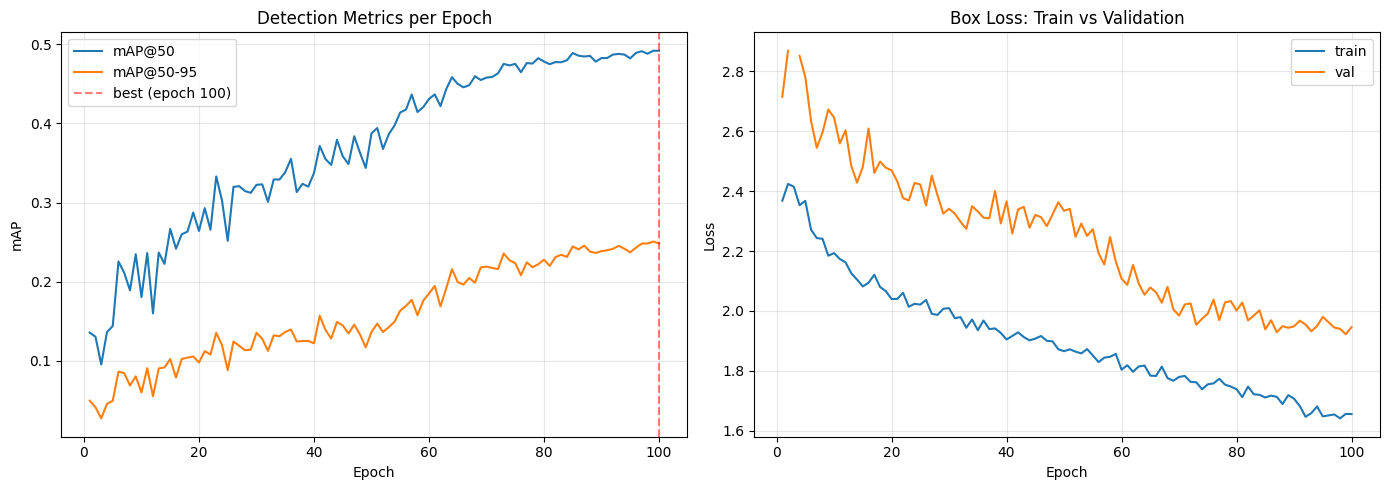

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = TRAIN_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

best_epoch = df["metrics/mAP50(B)"].idxmax()
best = df.iloc[best_epoch]

print("Training metrics summary:")
print(f"  Best epoch       : {best_epoch + 1}")
print(f"  mAP@50           : {best.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP@50-95        : {best.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision        : {best.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall           : {best.get('metrics/recall(B)', 0):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df.index + 1, df["metrics/mAP50(B)"], label="mAP@50")
ax1.plot(df.index + 1, df["metrics/mAP50-95(B)"], label="mAP@50-95")
ax1.axvline(
    best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"best (epoch {best_epoch + 1})"
)
ax1.set(title="Detection Metrics per Epoch", xlabel="Epoch", ylabel="mAP")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df.index + 1, df["train/box_loss"], label="train")
ax2.plot(df.index + 1, df["val/box_loss"], label="val")
ax2.set(title="Box Loss: Train vs Validation", xlabel="Epoch", ylabel="Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Validation

Evaluate the model on the **test set** — data the model never saw during training.

Target metrics for a usable ship detector:
- **mAP@50 > 0.70** — good overall detection quality
- **Recall > Precision** — for maritime monitoring, missing a ship (false negative) is worse than a false alarm

In [23]:
from ultralytics import YOLO

val_model = YOLO(str(BEST_WEIGHTS))
val_results = val_model.val(
    data=str(DATA_YAML),
    split="test",
    conf=0.10,  # lower threshold prioritises recall over precision
    iou=0.5,
)

print(f"\nmAP@50    : {val_results.box.map50:.4f}")
print(f"mAP@50-95 : {val_results.box.map:.4f}")
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


val: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\labels.cache... 512 images, 0 backgrounds, 0 corrupt: 100%|██████████| 512/512 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 2768. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:09<00:00,  3.41it/s]


                   all        512       2768      0.748      0.467      0.616      0.339
Speed: 0.6ms preprocess, 12.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\leona\source\repos\diplo-mod-2\runs\detect\val2

mAP@50    : 0.6163
mAP@50-95 : 0.3389
Precision : 0.7478
Recall    : 0.4675


---
## Section 7: Inference with the Fine-tuned Model

In [14]:
from ultralytics import YOLO

test_images_dir = ROBOFLOW_DIR / "test" / "images"
inf_model = YOLO(str(BEST_WEIGHTS))

inf_results = inf_model.predict(
    source=str(test_images_dir),
    conf=0.10,
    iou=0.45,
    save=True,
    name="ship_detection_test",
    project=str(RUNS_DIR / "detect"),
)

predict_dirs = sorted(
    RUNS_DIR.glob("detect/ship_detection_test*/"), key=lambda p: p.stat().st_mtime
)
latest_predict = predict_dirs[-1]
print(f"Predictions saved to: {latest_predict}")


image 1/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\0150b2c24_jpg.rf.7f45d612069a712643ea16a20a5ed840.jpg: 640x640 (no detections), 12.0ms
image 2/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.09bb8db398c9799c6ad73c43d0cf5ce0.jpg: 640x640 1 ship, 17.6ms
image 3/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.99bd39aed3fef732f1be4c1c17da5270.jpg: 640x640 1 ship, 21.7ms
image 4/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.b25229bd9f4e0ee92fa515edd146529a.jpg: 640x640 1 ship, 15.0ms
image 5/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\04e7626b1_jpg.rf.bc7c76ff2519bc79fd2a3122b62100b1.jpg: 640x640 1 ship, 13.0ms
image 6/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\056949650_jpg.rf.8bf859c61ffed88571ec88ee3081e71

Showing 6 sample predictions:


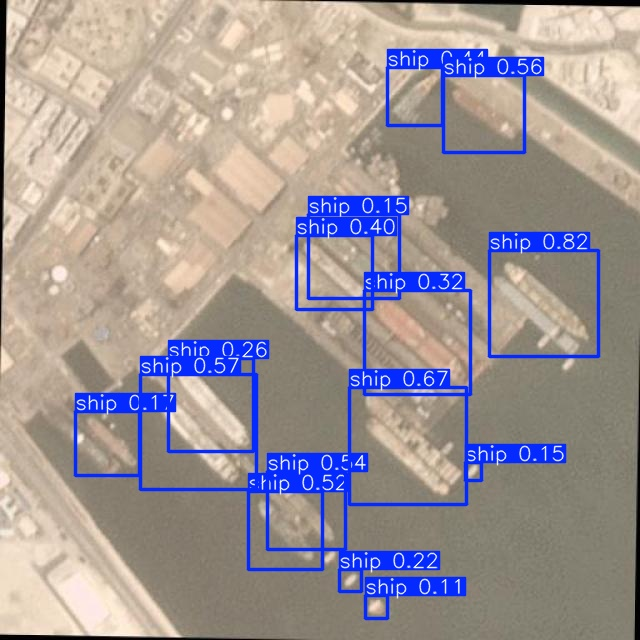

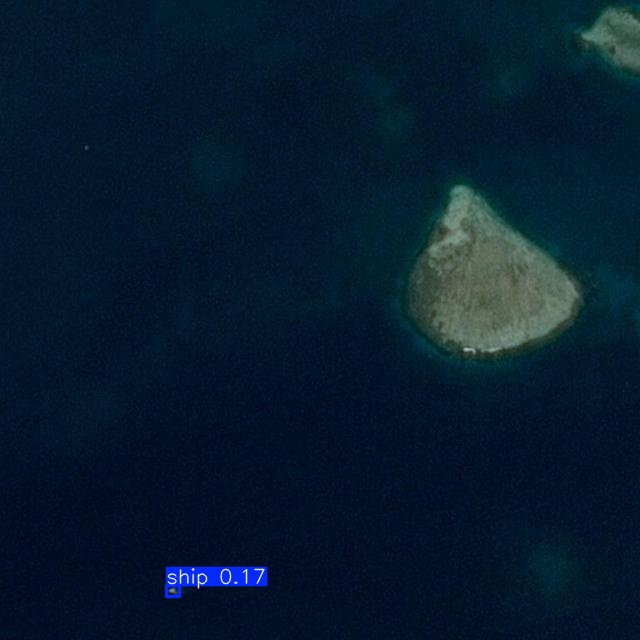

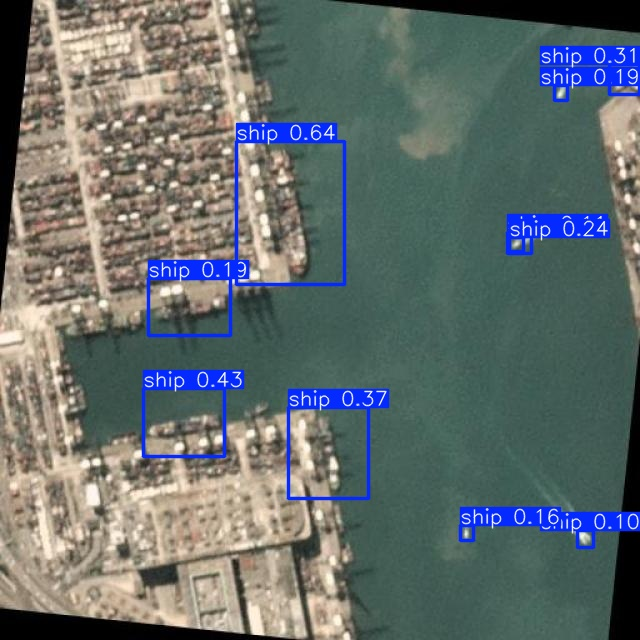

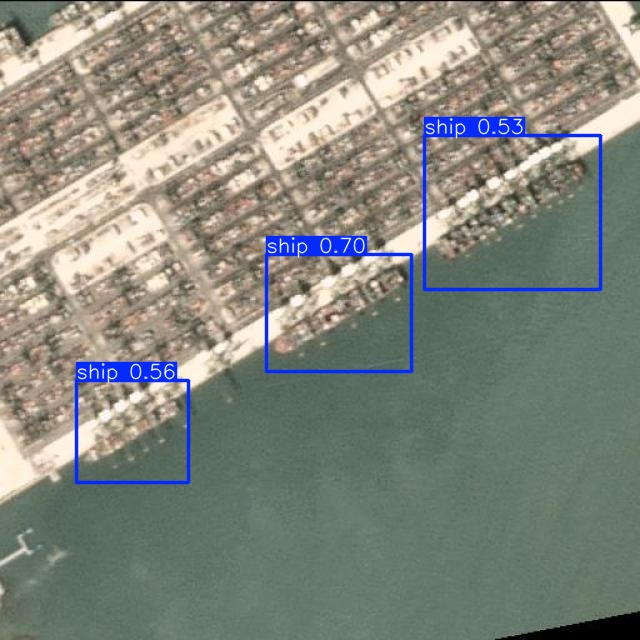

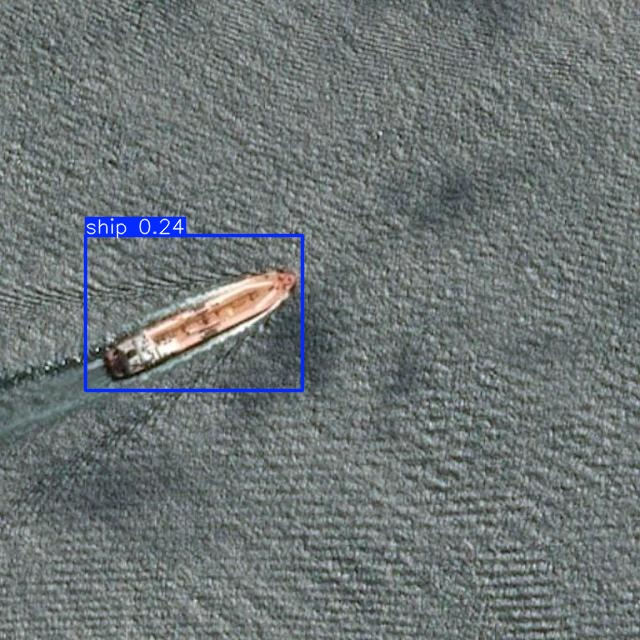

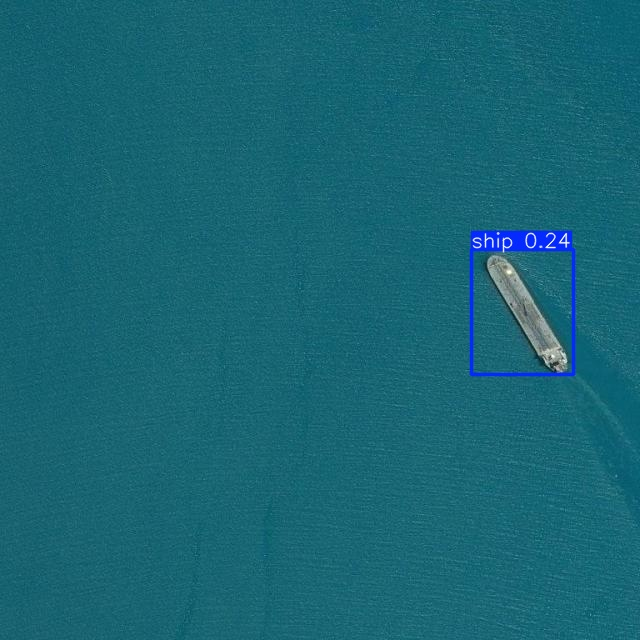

In [15]:
result_images = list(latest_predict.glob("*.jpg")) + list(latest_predict.glob("*.png"))
sample = random.sample(result_images, min(6, len(result_images)))

print(f"Showing {len(sample)} sample predictions:")
for img_path in sample:
    display(IPyImage(filename=str(img_path), width=700))
    print()


0: 640x640 5 ships, 179.5ms
Speed: 4.8ms preprocess, 179.5ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Image : 20190424_051033_0f4b_3B_Visual_2_png_jpg.rf.a09e3ecbde78fcdd84153901f7515d9f.jpg
Ships detected: 5
  Ship 1: bbox=(207,330,287,403)  size=80x72px  conf=0.54
  Ship 2: bbox=(343,224,448,323)  size=105x99px  conf=0.50
  Ship 3: bbox=(467,414,496,440)  size=29x26px  conf=0.35
  Ship 4: bbox=(88,606,136,640)  size=48x34px  conf=0.35
  Ship 5: bbox=(535,337,553,353)  size=17x17px  conf=0.29


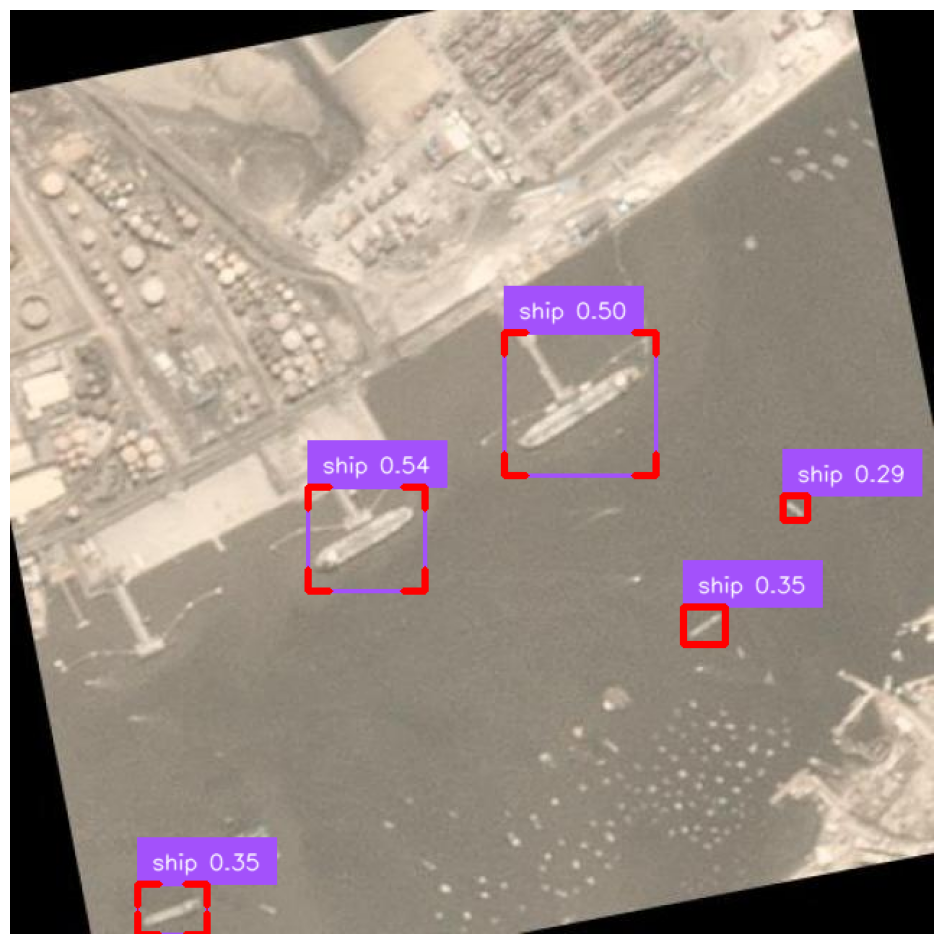

In [16]:
# Programmatic inference with supervision for richer visualisation
import supervision as sv

test_images = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.png"))
img_path = random.choice(test_images)
image = Image.open(img_path).convert("RGB")

result = inf_model.predict(image, conf=0.25, iou=0.45)[0]
detections = sv.Detections.from_ultralytics(result)

print(f"Image : {img_path.name}")
print(f"Ships detected: {len(detections)}")
assert detections.confidence is not None
for i, (box, conf) in enumerate(zip(detections.xyxy, detections.confidence), start=1):
    x1, y1, x2, y2 = box
    print(
        f"  Ship {i}: bbox=({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})  "
        f"size={x2 - x1:.0f}x{y2 - y1:.0f}px  conf={conf:.2f}"
    )

labels = [f"ship {c:.2f}" for c in detections.confidence]
annotated = image.copy()
annotated = sv.BoxAnnotator(thickness=2).annotate(annotated, detections)
annotated = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_scale=0.5).annotate(
    annotated, detections, labels
)
annotated = sv.BoxCornerAnnotator(color=sv.Color.RED).annotate(annotated, detections)
sv.plot_image(annotated, size=(12, 12))

---
## Section 8: Confidence Threshold Analysis

- **Low conf (0.10–0.20):** more detections, more false positives
- **High conf (0.50–0.70):** higher precision, may miss small ships

For maritime surveillance, **recall is prioritised** — missing a ship is worse than a false alarm.
Recommended range: **0.25–0.40**.

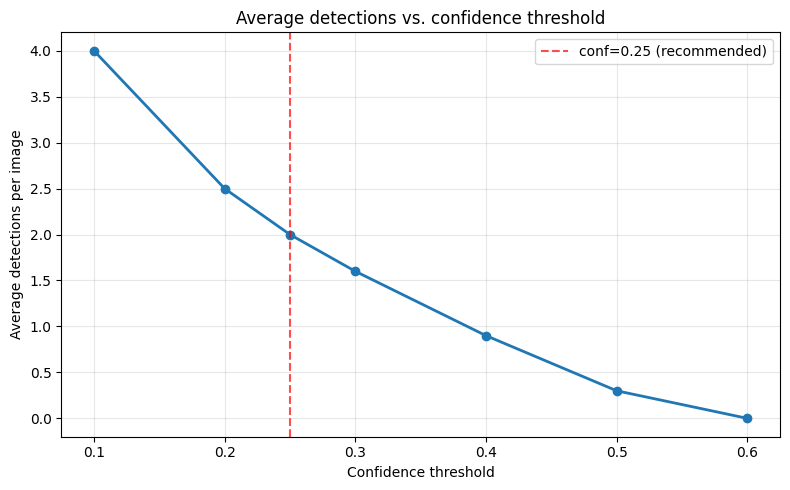

In [17]:
sweep_sample = random.sample(test_images, min(20, len(test_images)))
conf_values = [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]
avg_detections = []

for conf in conf_values:
    total = sum(
        len(inf_model.predict(str(p), conf=conf, verbose=False)[0].boxes) for p in sweep_sample
    )
    avg_detections.append(total / len(sweep_sample))

plt.figure(figsize=(8, 5))
plt.plot(conf_values, avg_detections, marker="o", linewidth=2)
plt.axvline(0.25, color="red", linestyle="--", alpha=0.7, label="conf=0.25 (recommended)")
plt.xlabel("Confidence threshold")
plt.ylabel("Average detections per image")
plt.title("Average detections vs. confidence threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Next Steps

- **More annotated data** — the single most effective improvement
- **Higher resolution** — try `imgsz=1280` with `batch=8` for small ships
- **SAHI** — sliced inference for very high-resolution satellite images: `pip install sahi`
- **ONNX export** — CPU inference without PyTorch: `model.export(format='onnx')`
- **TensorRT export** — optimised NVIDIA inference: `model.export(format='engine')`
- **Multi-class extension** — add `cargo_ship`, `tanker`, `sailboat` classes with more annotations

**References:**
- [Ultralytics YOLO11 Docs](https://docs.ultralytics.com)
- [Roboflow Universe — ship datasets](https://universe.roboflow.com/search?q=ship+satellite)
- [SAHI for small objects](https://github.com/obss/sahi)